In [ ]:
"""
Why do OT and the kNN pseudotime gradient give such similar fields, and
under what conditions should they diverge?

Run:  conda activate velot_test && python ot_vs_gradient_diagnostics.py

Everything runs on synthetic bifurcations, where the true velocity is
known analytically, so the comparison does not depend on CBDir/ICCoh -
the two metrics the reviewers say are coupled to the objective.

THE HYPOTHESIS UNDER TEST
-------------------------
Both estimators have the same form,

    v_i = sum_j w_ij (x_j - x_i),

and differ only in w. The gradient uses uniform weights over forward kNN
neighbours. OT uses the row-normalised Sinkhorn plan, whose kernel is

    K_ij = exp(-C_ij / eps),
    C_ij = d2_ij / d2_max  +  lambda_time * 1[tau_i > tau_j]
                           +  lambda_knn  * 1[j not in kNN(i)].

With lambda_time = lambda_knn = 1 and eps = 0.1, the two indicator terms
contribute exp(-10) ~ 5e-5, so backward and off-manifold targets are
effectively excluded. What remains inside the allowed set is
exp(-d2/(d2_max * eps)). If the window is compact, d2/d2_max has little
spread and those weights are nearly uniform.

Prediction: OT reduces to "uniform weights over forward kNN targets",
which is the gradient baseline. The one thing OT still does that the
gradient cannot is enforce the COLUMN marginal - each target cell
receives a fixed share of mass - which stops many sources from piling
onto the same attractive target. That constraint is slack under uniform
density and binds under imbalance.

So OT should match the gradient on balanced data and beat it on
imbalanced data. Sweeps below test exactly that.
"""
from __future__ import annotations

import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import scanpy as sc
import ot as pot
import velot

sc.settings.verbosity = 0

HERE = os.getcwd()
OUT = os.path.join(HERE, "results")
os.makedirs(OUT, exist_ok=True)

SEEDS = (0, 1, 2)


# =====================================================================
# Ground truth
# =====================================================================
def true_velocity(adata, slopes=(2.0, -2.0)):
    """Analytic unit velocity for velot.datasets.synthetic_bifurcation,
    expressed in the SAME basis as adata.obsm['X_pca'].

    In feature space the true motion is (1, slope, 0, 0, ...): the extra
    dimensions are pure noise and carry no dynamics. When extra
    dimensions are present the dataset builder runs a real PCA, which
    rotates the axes, so the truth must be pushed through the loadings
    rather than compared to the first two PCs.
    """
    lab = adata.obs["celltype"].astype(str).values
    n_feat = adata.shape[1]
    Vf = np.zeros((adata.n_obs, n_feat))
    Vf[lab == "Root", 0] = 1.0
    for i, s in enumerate(slopes):
        m = lab == f"Branch_{i+1}"
        Vf[m, 0] = 1.0
        Vf[m, 1] = s

    if "PCs" in adata.varm:                      # extra_dimensions > 0
        V = Vf @ np.asarray(adata.varm["PCs"])   # (n_obs, n_comps)
    else:                                        # X_pca is X itself
        V = Vf[:, :adata.obsm["X_pca"].shape[1]]

    nrm = np.linalg.norm(V, axis=1, keepdims=True)
    return V / np.clip(nrm, 1e-12, None)


def cosine_rows(A, B):
    na = np.linalg.norm(A, axis=1)
    nb = np.linalg.norm(B, axis=1)
    ok = (na > 1e-12) & (nb > 1e-12)
    out = np.full(len(A), np.nan)
    out[ok] = (A[ok] * B[ok]).sum(1) / (na[ok] * nb[ok])
    return out


def truth_agreement(adata, vkey, slopes=(2.0, -2.0)):
    """Mean cosine between an inferred field and the true field, both in
    the PCA basis the velocity was computed in."""
    T = true_velocity(adata, slopes)
    V = np.asarray(adata.obsm[vkey])[:, :T.shape[1]]
    T = T[:, :V.shape[1]]
    c = cosine_rows(V, T)
    return float(np.nanmean(c)), float(np.nanmean(c > 0))


# =====================================================================
# Matched runs - identical smoother on both sides
# =====================================================================
SHARED = dict(
    basis="X_pca",
    smooth=True,
    n_clusters=1,
    spatial_key="clusters_id",
    window_size=100,
    min_window_size=20,
    overlap_fraction=0.0,
    tail_handling="drop",
    tail_threshold=20,
    n_epochs=150,
    lambda_smooth=0.5,
    lambda_curl=0.5,
    lambda_divergence=0.0,
    k_smooth=30,
    project_umap=True,
    verbose=True,
)


def run_pair(adata, reg=0.1, grad_k=30, seed=0, **over):
    """Run OT and gradient with byte-identical downstream settings."""
    kw = {**SHARED, **over, "random_state": seed}

    a_ot = adata.copy()
    velot.tl.velocity(a_ot, method="ot", reg=reg, lambda_time=1.0,
                      lambda_knn=1.0, **kw)

    a_gr = adata.copy()
    velot.tl.velocity(a_gr, method="gradient", gradient_mode="knn",
                      gradient_k=grad_k, **kw)
    return a_ot, a_gr


def make_data(n_root=400, n_branch=(300, 300), extra_dim=0, seed=0,
              n_neighbors=30, noise=0.05):
    adata = velot.datasets.synthetic_bifurcation(
        root_density=n_root, branch_densities=list(n_branch),
        branch_positions=(2.0, 2.0), branch_slopes=(2.0, -2.0),
        noise_level=noise, extra_dimensions=extra_dim,
        n_neighbors=n_neighbors, seed=seed,
    )
    adata.obs["clusters_id"] = adata.obs["celltype"].cat.codes
    adata.obs["pseudotime"] = adata.obs["true_pseudotime"].values
    return adata


# =====================================================================
# A. Are the two raw fields the same object?
# =====================================================================
def part_a_raw_agreement():
    print("\n" + "=" * 74)
    print("A. RAW-LEVEL AGREEMENT  (before any MLP)")
    print("=" * 74)
    print("If the raw fields already agree, nothing downstream can separate")
    print("them, and the question is settled at the estimator level.\n")

    rows = []
    for seed in SEEDS:
        adata = make_data(seed=seed)
        a_ot, a_gr = run_pair(adata, seed=seed)

        raw = cosine_rows(a_ot.obsm["velot_velocity_raw_pca"],
                          a_gr.obsm["velot_velocity_raw_pca"])
        sm = cosine_rows(a_ot.obsm["velot_velocity_pca"],
                         a_gr.obsm["velot_velocity_pca"])
        t_ot = truth_agreement(a_ot, "velot_velocity_pca")
        t_gr = truth_agreement(a_gr, "velot_velocity_pca")
        rows.append(dict(seed=seed,
                         raw_cos=np.nanmean(raw), smooth_cos=np.nanmean(sm),
                         ot_vs_truth=t_ot[0], grad_vs_truth=t_gr[0],
                         ot_signok=t_ot[1], grad_signok=t_gr[1]))

    df = pd.DataFrame(rows)
    print(df.to_string(index=False, float_format=lambda v: f"{v:7.4f}"))
    print(f"\n  mean cosine(v_OT_raw, v_grad_raw)      = {df.raw_cos.mean():.4f}")
    print(f"  mean cosine(v_OT_smooth, v_grad_smooth) = {df.smooth_cos.mean():.4f}")
    print(f"  OT   vs ground truth: {df.ot_vs_truth.mean():.4f}")
    print(f"  grad vs ground truth: {df.grad_vs_truth.mean():.4f}")
    print(f"  difference          : "
          f"{df.ot_vs_truth.mean() - df.grad_vs_truth.mean():+.4f}")
    df.to_csv(f"{OUT}/A_raw_agreement.csv", index=False)
    return df


# =====================================================================
# B. What do the transport plans actually look like?
# =====================================================================
def _cost_matrix(X, idx_s, idx_t, tau, knn_adj, lam_t=1.0, lam_k=1.0):
    """Replica of the cost in velot.tl._ot_velocity_pair.
    Keep in sync if that function changes."""
    C = pot.dist(X[idx_s], X[idx_t], metric="sqeuclidean")
    cmax = C.max()
    if cmax > 0:
        C = C / cmax
    C[(tau[idx_s][:, None] - tau[idx_t][None, :]) > 0] += lam_t
    if knn_adj is not None:
        loc = knn_adj[idx_s][:, idx_t]
        loc = loc.toarray() if hasattr(loc, "toarray") else loc
        C[np.asarray(loc) == 0] += lam_k
    return C


def part_b_plan_structure(regs=(0.01, 0.05, 0.1, 0.2, 0.5, 1.0)):
    print("\n" + "=" * 74)
    print("B. TRANSPORT-PLAN STRUCTURE vs SINKHORN EPSILON")
    print("=" * 74)
    print("How far is the row-normalised plan from uniform-over-support?")
    print("eff. support = exp(row entropy): the number of target cells a")
    print("source effectively spreads its mass over.\n")

    adata = make_data(seed=0)
    velot.tl.build_windows(adata, basis="X_pca", n_clusters=1,
                           window_size=200, min_window_size=20,
                           overlap_fraction=0.0, tail_handling="drop",
                           tail_threshold=20)
    X = adata.obsm["X_pca"]
    tau = adata.obs["pseudotime"].values
    knn = adata.obsp["connectivities"] if "connectivities" in adata.obsp else None
    pairs = adata.uns["velot_windows"]["pairs"]

    rows = []
    for reg in regs:
        effs, tops, kls = [], [], []
        for idx_s, idx_t in pairs:
            idx_s, idx_t = np.asarray(idx_s), np.asarray(idx_t)
            C = _cost_matrix(X, idx_s, idx_t, tau, knn)
            a = np.ones(len(idx_s)) / len(idx_s)
            b = np.ones(len(idx_t)) / len(idx_t)
            try:
                P = pot.sinkhorn(a, b, C, reg=reg, numItermax=500, stopThr=1e-6)
            except Exception:
                continue
            if not np.isfinite(P).all() or P.sum() < 1e-12:
                continue
            R = P / np.clip(P.sum(1, keepdims=True), 1e-30, None)

            H = -(R * np.log(np.clip(R, 1e-30, None))).sum(1)
            effs.append(np.exp(H).mean())
            tops.append(R.max(1).mean())

            supp = (C < 1.0)              # targets the cost has NOT excluded
            ns = np.clip(supp.sum(1), 1, None)
            U = supp / ns[:, None]
            kl = (R * np.log(np.clip(R, 1e-30, None) /
                             np.clip(U, 1e-30, None))).sum(1)
            kls.append(np.nanmean(kl[np.isfinite(kl)]))

        rows.append(dict(eps=reg, eff_support=np.mean(effs),
                         top1_mass=np.mean(tops),
                         KL_to_uniform_on_support=np.mean(kls)))

    df = pd.DataFrame(rows)
    print(df.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))
    print("\n  KL -> 0 means the plan IS the uniform/mean assignment,")
    print("  i.e. OT has collapsed onto the gradient baseline.")
    df.to_csv(f"{OUT}/B_plan_structure.csv", index=False)
    return df


# =====================================================================
# C. Sweeps: epsilon, dimension, density, imbalance, k
# =====================================================================
def _sweep(name, variants, build, note):
    print("\n" + "=" * 74)
    print(name)
    print("=" * 74)
    print(note + "\n")
    rows = []
    for label, kwargs in variants:
        for seed in SEEDS:
            adata, runkw = build(seed, **kwargs)
            a_ot, a_gr = run_pair(adata, seed=seed, **runkw)
            raw = np.nanmean(cosine_rows(
                a_ot.obsm["velot_velocity_raw_pca"],
                a_gr.obsm["velot_velocity_raw_pca"]))
            t_ot = truth_agreement(a_ot, "velot_velocity_pca")[0]
            t_gr = truth_agreement(a_gr, "velot_velocity_pca")[0]
            rows.append(dict(variant=label, seed=seed, raw_cos=raw,
                             ot_truth=t_ot, grad_truth=t_gr,
                             ot_minus_grad=t_ot - t_gr))
    df = pd.DataFrame(rows)
    agg = df.groupby("variant", sort=False).agg(
        raw_cos=("raw_cos", "mean"),
        ot_truth=("ot_truth", "mean"),
        grad_truth=("grad_truth", "mean"),
        ot_minus_grad=("ot_minus_grad", "mean"),
        sd=("ot_minus_grad", "std"))
    print(agg.to_string(float_format=lambda v: f"{v:8.4f}"))
    df.to_csv(f"{OUT}/{name.split('.')[0].strip()}_raw.csv", index=False)
    return agg


def part_c_epsilon():
    return _sweep(
        "C1. SINKHORN EPSILON",
        [(f"eps={e}", dict(reg=e)) for e in (0.01, 0.05, 0.1, 0.2, 0.5)],
        lambda seed, reg: (make_data(seed=seed), dict(reg=reg)),
        "Smaller eps -> sharper plan -> should move further from the mean.\n"
        "If raw_cos stays ~1 even at eps=0.01, the cost geometry, not the\n"
        "regularisation, is what makes the two coincide.")


def part_c_dimension():
    def build(seed, extra):
        return make_data(extra_dim=extra, seed=seed), {}
    return _sweep(
        "C2. AMBIENT DIMENSION",
        [(f"extra_dim={d}", dict(extra=d)) for d in (0, 5, 20, 50)],
        build,
        "Distances concentrate as dimension grows, so d2/d2_max flattens\n"
        "and the Sinkhorn kernel tends to uniform. Expect the two methods\n"
        "to converge - i.e. raw_cos INCREASES with dimension.")


def part_c_density():
    def build(seed, n):
        return make_data(n_root=n, n_branch=(int(n * .75), int(n * .75)),
                         seed=seed), {}
    return _sweep(
        "C3. CELL DENSITY",
        [(f"n_root={n}", dict(n=n)) for n in (100, 200, 400, 800)],
        build,
        "At high density the forward kNN is a tiny, locally uniform patch,\n"
        "so the mean and the OT barycentre coincide. Sparse data should\n"
        "separate them if anything does.")


def part_c_imbalance():
    def build(seed, frac):
        n2 = max(20, int(300 * frac))
        return make_data(n_root=400, n_branch=(300, n2), seed=seed), {}
    return _sweep(
        "C4. BRANCH IMBALANCE  <-- the regime where OT should win",
        [(f"rare_branch={f:.2f}", dict(frac=f))
         for f in (1.0, 0.5, 0.25, 0.1, 0.05)],
        build,
        "OT's column marginal forces every target cell to receive mass, so\n"
        "a rare branch cannot be ignored. The gradient has no such\n"
        "constraint. If OT has an advantage anywhere, it is here.")


def part_c_k():
    return _sweep(
        "C5. GRADIENT NEIGHBOURHOOD SIZE k",
        [(f"grad_k={k}", dict(k=k)) for k in (5, 15, 30, 60)],
        lambda seed, k: (make_data(seed=seed), dict(grad_k=k)),
        "How much of the agreement is just 'k is large enough to average\n"
        "away the difference'?")


# =====================================================================
# D. Magnitude
# =====================================================================
def part_d_magnitude():
    print("\n" + "=" * 74)
    print("D. VELOCITY MAGNITUDE  (nothing is normalised anywhere)")
    print("=" * 74)
    print("The MLP regression term is an unweighted L2 on RAW magnitudes:")
    print("    loss_reg = sum_i c_i ||f(x_i) - v_i||^2 / sum_i c_i")
    print("so cells with large ||v|| dominate the fit. If the same few")
    print("cells dominate for both estimators, the smoothed fields are")
    print("pulled together regardless of how the weights differ.\n")

    rows = []
    for seed in SEEDS:
        adata = make_data(seed=seed)
        a_ot, a_gr = run_pair(adata, seed=seed)
        for tag, a in (("ot", a_ot), ("gradient", a_gr)):
            n = np.linalg.norm(a.obsm["velot_velocity_raw_pca"], axis=1)
            nz = n[n > 0]
            sq = nz ** 2
            order = np.argsort(sq)[::-1]
            top1 = sq[order[:max(1, len(sq) // 100)]].sum() / sq.sum()
            rows.append(dict(
                seed=seed, method=tag,
                median=np.median(nz), p99=np.percentile(nz, 99),
                p99_over_median=np.percentile(nz, 99) / np.median(nz),
                max_over_median=nz.max() / np.median(nz),
                loss_share_top1pct=top1))
    df = pd.DataFrame(rows)
    agg = df.groupby("method").mean(numeric_only=True).drop(columns="seed")
    print(agg.to_string(float_format=lambda v: f"{v:9.4f}"))
    print("\n  loss_share_top1pct = fraction of the regression loss carried")
    print("  by the heaviest 1% of cells. Above ~0.3 the MLP is largely")
    print("  fitting those cells, and the estimator choice matters less.")
    df.to_csv(f"{OUT}/D_magnitude.csv", index=False)

    print("\n  --- re-run with raw vectors unit-normalised before the MLP ---")
    print("  If normalising SEPARATES the two methods, the heavy tail was")
    print("  masking a real difference. If not, they really are the same")
    print("  estimator on this data.\n")
    rows = []
    for seed in SEEDS:
        adata = make_data(seed=seed)
        a_ot, a_gr = run_pair(adata, seed=seed)
        fields = {}
        for tag, a in (("ot", a_ot), ("gradient", a_gr)):
            V = a.obsm["velot_velocity_raw_pca"].copy()
            nrm = np.linalg.norm(V, axis=1, keepdims=True)
            keep = nrm[:, 0] > 0
            V[keep] /= nrm[keep]
            a.obsm["velot_velocity_raw_pca"] = V
            velot.tl.smooth_velocity(
                a, basis="pca", velocity_key="velot_velocity_raw_pca",
                n_epochs=SHARED["n_epochs"],
                lambda_smooth=SHARED["lambda_smooth"],
                lambda_curl=SHARED["lambda_curl"],
                k_smooth=SHARED["k_smooth"],
                random_state=seed, verbose=False)
            fields[tag] = a.obsm["velot_velocity_pca"]
            rows.append(dict(seed=seed, method=tag,
                             vs_truth=truth_agreement(
                                 a, "velot_velocity_pca")[0],
                             cos_ot_vs_grad=np.nan))
        rows[-1]["cos_ot_vs_grad"] = float(np.nanmean(
            cosine_rows(fields["ot"], fields["gradient"])))
    dfn = pd.DataFrame(rows)
    print(dfn.groupby("method").vs_truth.mean().to_string(
        float_format=lambda v: f"{v:.4f}"))
    print(f"\n  cosine(OT, gradient) after normalisation = "
          f"{dfn.cos_ot_vs_grad.mean():.4f}")
    dfn.to_csv(f"{OUT}/D_magnitude_normalised.csv", index=False)
    return agg

In [ ]:
# =====================================================================
def main():
    print(__doc__)
    part_a_raw_agreement()
    part_b_plan_structure()
    part_c_epsilon()
    part_c_dimension()
    part_c_density()
    part_c_imbalance()
    part_c_k()
    part_d_magnitude()
    print("\n" + "=" * 74)
    print(f"All tables written to {OUT}")
    print("=" * 74)

if __name__ == "__main__":
    main()

In [53]:
adata = make_data(seed=0)
adata

AnnData object with n_obs × n_vars = 1000 × 2
    obs: 'celltype', 'true_pseudotime', 'clusters_id', 'pseudotime'
    uns: 'neighbors', 'umap'
    obsm: 'X_spatial_true', 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

In [54]:
adata.obsm['velot_velocity_raw_pca'] = true_velocity(adata)

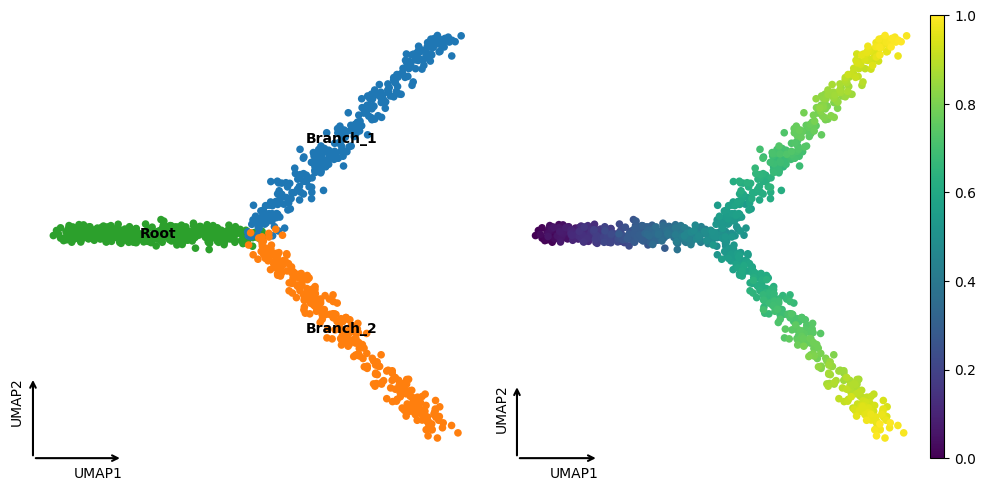

In [55]:
velot.pl.dataset_overview(adata, "celltype", "pca")

In [56]:
ad_ot, ad_gr = run_pair(adata)

VelOT: Computing velocity field
  Estimator: ot
  Basis: X_pca (2D)
  Cells: 1000
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Using precomputed spatial labels from 'clusters_id': 3 clusters
  Built 7 window pairs across 3 clusters (skipped 0 small clusters)
  Window size: 100, step: 100

[2/4] Computing OT velocity...
  OT velocity computed: 700 cells with velocity, 300 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
Found torch compatible version. Running on cuda device
    epoch 50/150: total=1.5439 reg=0.0288 smooth=0.0000 curl=0.0001
    epoch 100/150: total=1.1953 reg=0.0260 smooth=0.0000 curl=0.0000
    epoch 150/150: total=0.8478 reg=0.0182 smooth=0.0000 curl=0.0000
  Smoothing complete: final total=0.8478

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (1000 cells)
  Velocity projected to UMAP (1000 cells)

VelOT: Done.
VelOT (gradient control): Computing velocity field
  Estimator: gradient / knn
  Basis: X_pca (2D)
  

In [57]:
import matplotlib.pyplot as plt

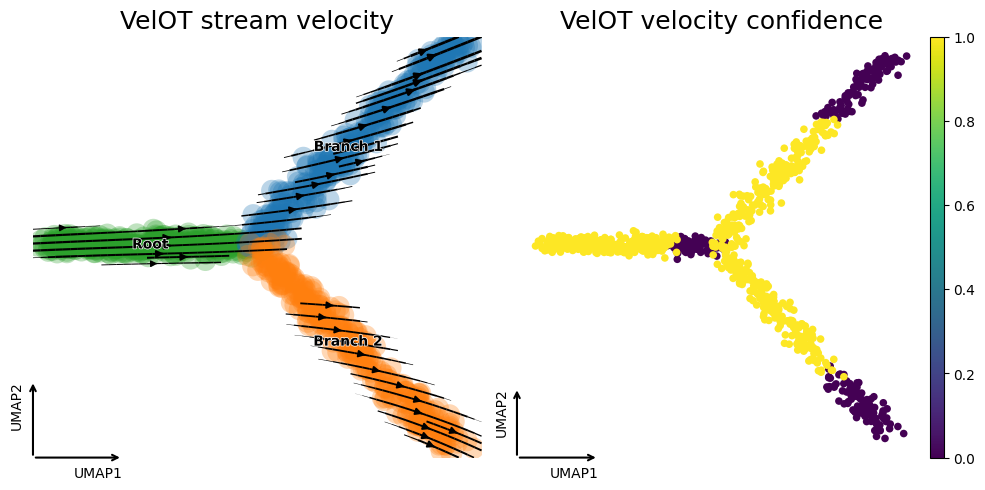

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_stream(ad_ot, color="celltype",
    title="VelOT stream velocity",
    figsize=(5,5), show=False, ax=axes[0], basis="pca"
)
velot.pl.dataset_overview_simple(ad_ot, color="velot_confidence",
    title="VelOT velocity confidence",
    show=False, ax=axes[1], basis="pca"
)

plt.tight_layout()
plt.show()

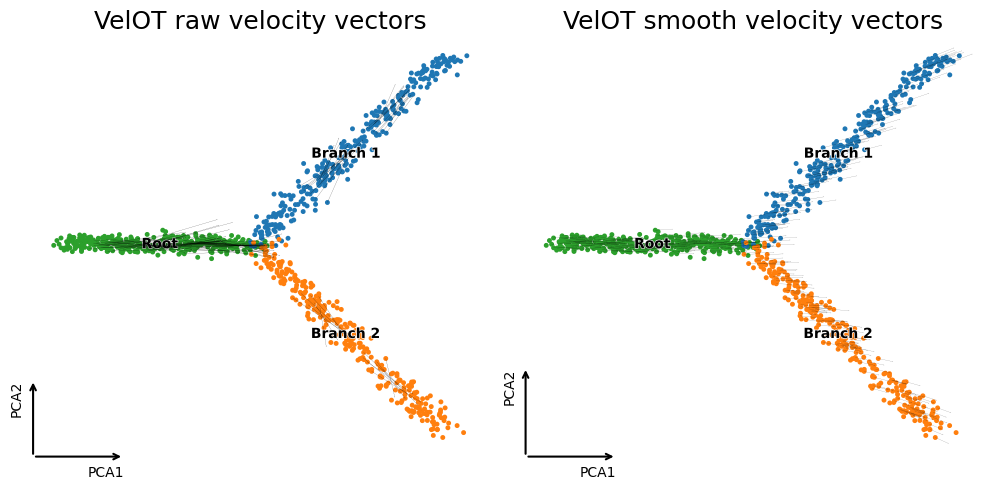

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

velot.pl.velocity_quiver(ad_ot,
    color="celltype", basis="pca", subsample=500,
    velocity_key=f"velot_velocity_raw_pca",
    title="VelOT raw velocity vectors",
    show=False, ax=axes[0], arrow_alpha=1, normalize_arrows=True
)
velot.pl.velocity_quiver(ad_ot,
    color="celltype", basis="pca", subsample=500,
    velocity_key=f"velot_velocity_pca",
    title="VelOT smooth velocity vectors",
    show=False, ax=axes[1]
)

plt.tight_layout()
plt.show()

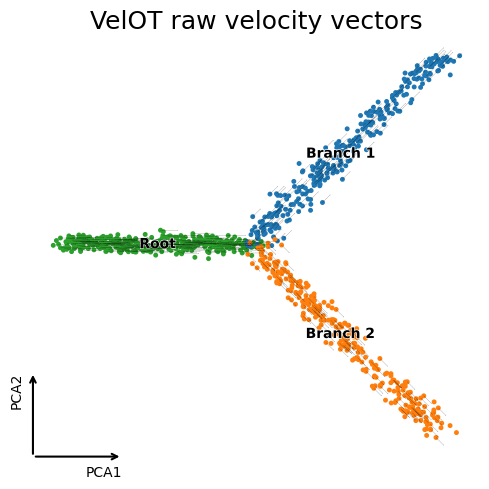

In [60]:
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

velot.pl.velocity_quiver(adata,
    color="celltype", basis="pca", subsample=500,
    velocity_key=f"velot_velocity_raw_pca",
    title="VelOT raw velocity vectors",
    show=False, ax=axes, arrow_alpha=1
)

plt.tight_layout()
plt.show()

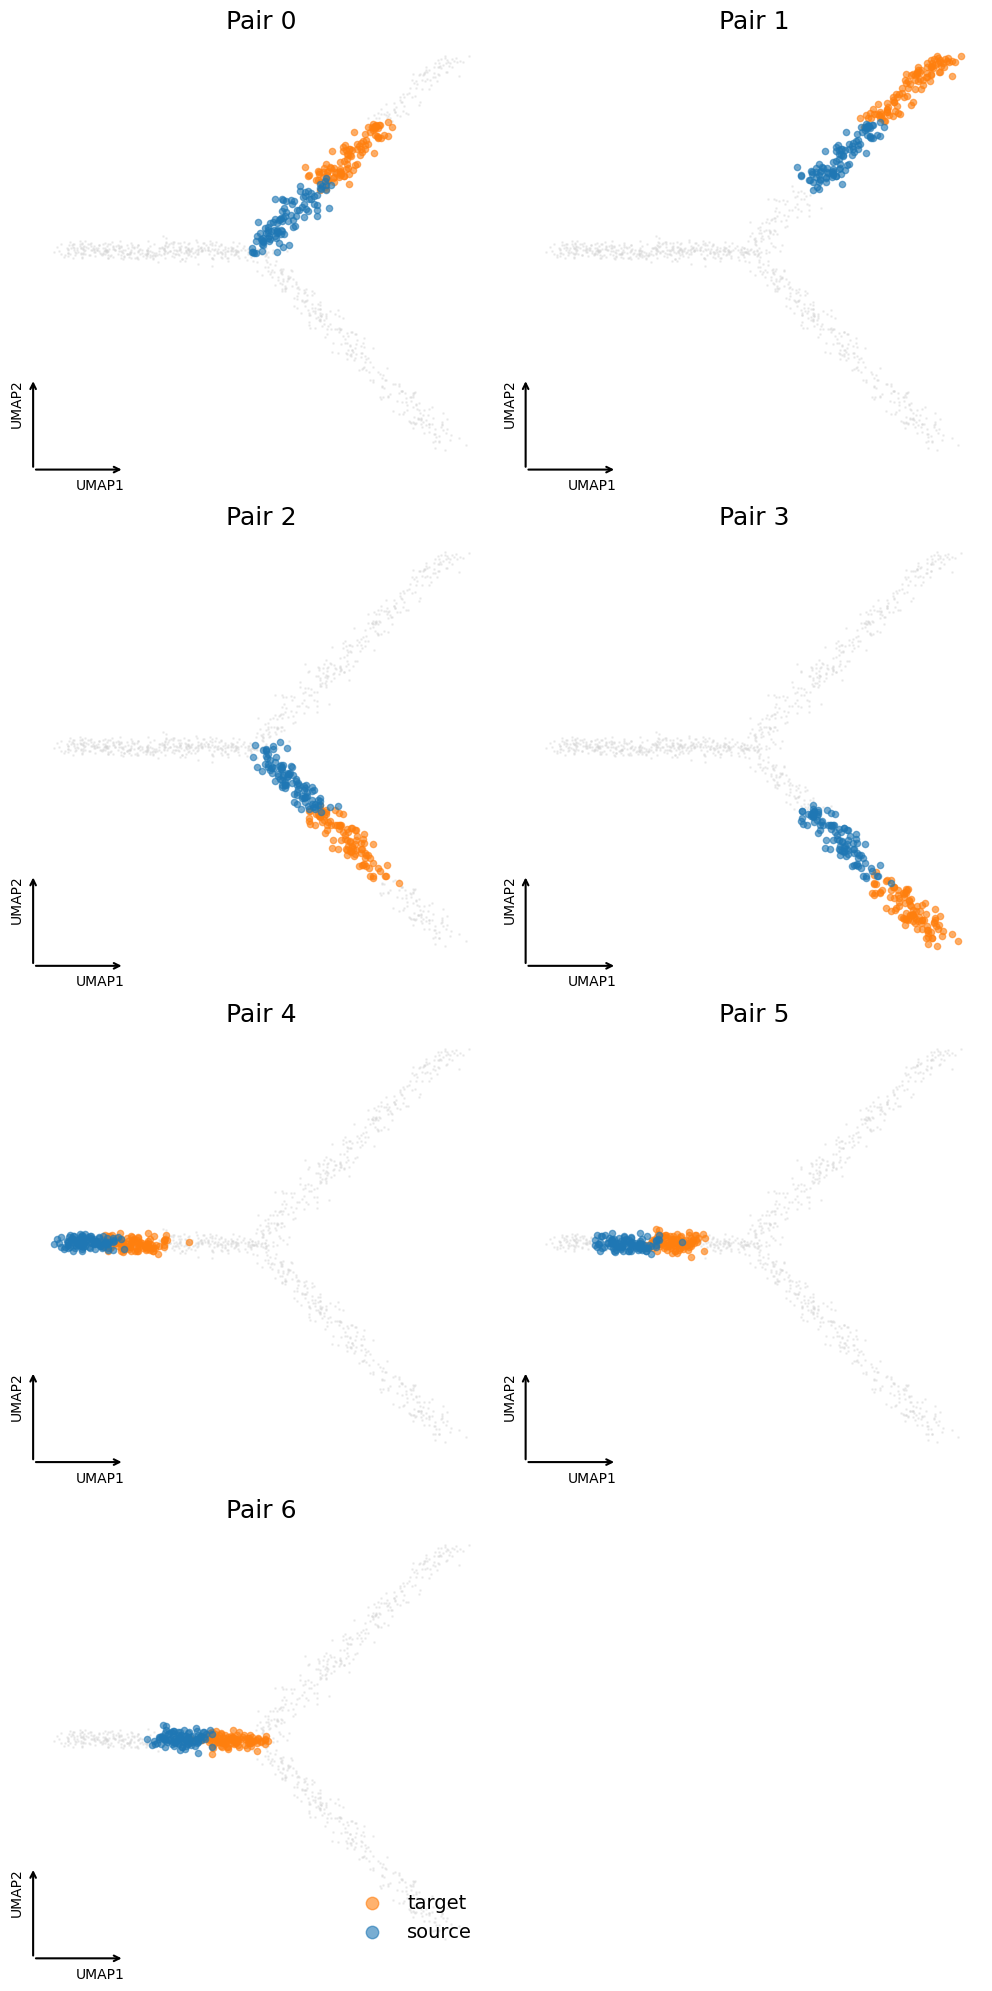

In [62]:
n_total_pairs = ad_ot.uns["velot_windows"]["n_pairs"]
pairs_to_show = tuple([i*1 for i in range(n_total_pairs)])
velot.pl.windows(ad_ot, basis="pca",
    pairs_to_show=pairs_to_show[:], ncols=2,
    pair_title=True, figsize_per_panel=(5,5), show=True
)